# Homework 3 Part 2 Task 1 - Classification
The dataset is from https://www.kaggle.com/c/GiveMeSomeCredit <br>
"Banks play a crucial role in market economies. They decide who can get finance and on what terms and can make or break investment decisions. For markets and society to function, individuals and companies need access to credit. Credit scoring algorithms, which make a guess at the probability of default, are the method banks use to determine whether or not a loan should be granted."  <br>
In this task, we will build classifiers to predict if someone will experience financial distress and therefore cannot pay off credit card (i.e. default). It is a binary classificaiton problem: default (class-1) or not default  (class-0) <br>
Learning Objective: <br>
1. It is almost computationally infeasible to do cross-validation for a large dataset <br>
    So, we divide the data into three sets: training, validation and testing sets <br>
    we do not repeat the above process. 
2. Real dataset is often imbalanced: class-i may have much more data samples than class-j. We set class_weight='balanced' if possible and use weighted classification accuracy, or do upsampling to balance data between classes. 
2. Given the model type (e.g. RandomForest), we find the best trainable-parameters on the training set  <br>
    and find the best hyper-parameters using training-validation strategy <br>
3. Then, we evaluate the trained model on the testing set using the best parameters <br>
4. To simply the task, you only need to find the best max_depth of DecisionTreeClassifier/RandomForestClassifier and the best n_neighbors of KNeighborsClassifier <br>
 <br>
This is a guided-task: <br>
You will see the output of a code cell and then figure out the code in that cell. <br>
In each code cell, there are instructions to help you. <br>
This is a very efficient and effective way to learn how to program with sk-learn

### Create your "signature"
Run the cell below but do NOT modify the cell. \
The signature needs to be displayed right below the cell in this file. \
You will get zero point if the signature is not displayed. 

In [1]:
import platform, socket, getpass
from time import time
from datetime import datetime
import random
signature=[socket.gethostbyname(socket.gethostname()),
           getpass.getuser(),
           datetime.now(),
           random.random()]
print(signature) 

['127.0.0.1', 'jademuyambo', datetime.datetime(2025, 11, 3, 17, 47, 59, 448879), 0.6468248915321203]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#every row of the table is a data sample (feature vector) from a person
df = pd.read_csv('cs_data.csv')
df.head()

,id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


#### handle nan (null) in data (i.e. missing values)
Some fields in the table are nan, which are missing values. <br>
For example, someone may not want to reveal monthly income to whoever made the table/survey, then the table got nan.

In [4]:
df.isnull().sum()

id                                          0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [5]:
#here, we use a simple method:
#replace nan in each column with median value of that column
#there are other methods in pandas and sklearn: interpolation in pandas and KNNImputer in sklearn
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
dfv=imputer.fit_transform(df.values)
df=pd.DataFrame(data=dfv, columns=df.columns)
df.isnull().sum()

id                                      0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

### We have a highly imbalanced dataset
139974 data samples in class-0 (normal) <br>
10026 data samples in class-1 (financial distress)

<Axes: >

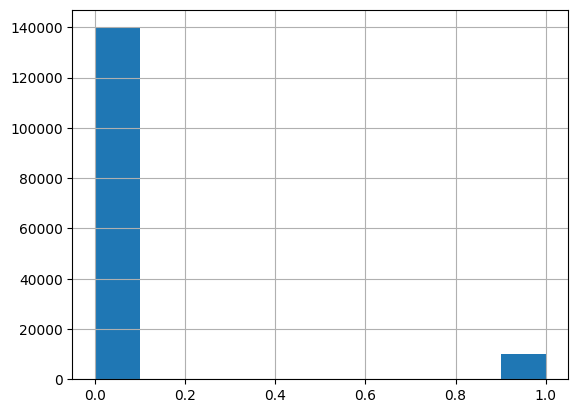

In [6]:
df['SeriousDlqin2yrs'].hist()

In [7]:
(df['SeriousDlqin2yrs']==0).sum()

np.int64(139974)

In [8]:
(df['SeriousDlqin2yrs']==1).sum()

np.int64(10026)

#### Classification Goal: predict 'SeriousDlqin2yrs' (Y) using the other features (X)

In [9]:
#'SeriousDlqin2yrs' is the target/class label, so it should not be in the input feature vector X
#'id' of a person is useless for the classification task
#so, we remove them from the table and get the input X
X=df.drop(['SeriousDlqin2yrs', 'id'], axis=1)
X.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45.0,2.0,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0
1,0.957151,40.0,0.0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0
2,0.658180,38.0,1.0,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0
3,0.233810,30.0,0.0,0.036050,3300.0,5.0,0.0,0.0,0.0,0.0
4,0.907239,49.0,1.0,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0


In [10]:
#Y is the target/class label
Y=df['SeriousDlqin2yrs']
Y.head()

0    1.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: SeriousDlqin2yrs, dtype: float64

In [11]:
# convert pandas dataframe/series to numpy array# sklearn functions may not work well with pandas data types
X=X.values
Y=Y.values

We split the data into training, validation and testing sets

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
#split X_train and Y_train into a 'pure' training set and a validation set
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=0)
#in the template, there is a different method to do the above split
print('train:', X_train.shape, Y_train.shape)
print('validation:', X_val.shape, Y_val.shape)
print('test:', X_test.shape, Y_test.shape)

train: (108000, 10) (108000,)
validation: (12000, 10) (12000,)
test: (30000, 10) (30000,)


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, make_scorer

weighted_scorer = make_scorer(balanced_accuracy_score)

In [14]:
rf = RandomForestClassifier(
    n_estimators=20,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1,
    bootstrap=True
)

In [15]:
param_grid = {
    "max_depth": [5,8,11,14,17],
    "min_samples_split": [2,10,50],
    "min_samples_leaf":[1,5,20],
    "max_features": ["sqrt", "log2", 0.5],
    "max_samples": [None, 0.6, 0.9],
}
    

In [16]:
gcv = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=weighted_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1,
refit=True
)
gcv.fit(X_train, Y_train)

print("Best CV balanced accuracy:", gcv.best_score_)
print("Best params:", gcv.best_estimator_)
best_rf = gcv.best_estimator_
best_rf

Fitting 3 folds for each of 405 candidates, totalling 1215 fits
Best CV balanced accuracy: 0.7847147531099591
Best params: RandomForestClassifier(class_weight='balanced', max_depth=8, max_features=0.5,
                       max_samples=0.9, min_samples_leaf=20, n_estimators=20,
                       n_jobs=-1, random_state=0)


,n_estimators,20
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_test_pred = best_rf.predict(X_test)
cm_test = confusion_matrix(Y_test, y_test_pred)
test_bal_acc = balanced_accuracy_score(Y_test, y_test_pred)

print("Test balanced accuracy:", test_bal_acc)
cm_test

Test balanced accuracy: 0.7701472215801096


array([[22344,  5613],
       [  529,  1514]])